# The shared tumour — one spatial simulation behind every science notebook

Every *science* notebook in this folder (`combining_scdna_scrna`, `wgd_allele_cna`, `gene_programs`,
`tree_inference_dna`, `scrna_visium_integration`, and the two `cohort_*` notebooks) is built on **this
one spatially-structured tumour**, grown deterministically by `base_sim.grow_base_tumor()`. The other
seven tutorials (`01_pipeline_walkthrough`, `02_tumor_growth`, `03_data_overview`, the `assay_*`
notebooks, `reads`) cover the *mechanics*; these show the **science** — what each modality lets you
recover, and how iscc's ground truth lets you score it honestly.

Rather than ship a giant CSV, we **re-grow** the tumour on demand: ~1 minute, byte-for-byte
reproducible, so every notebook shares the identical substrate.

## The model: a breast **DCIS** (ductal carcinoma in situ)

The substrate is a duct cross-section. An **epithelial ring** (the basement membrane) sits at
`structure_radius`; the cancer grows from a single founder into the **empty lumen** inside it; **stroma**
fills the outside. A cancer cell that lands on a normal-occupied deme must be fit enough to survive the
crowding there, so **breaching the ring into the stroma is fitness-gated** — an *in situ* lesion that
only **microinvades** where a clone is fit enough (see the `cell type` panel below).

| feature (`notebooks/base_sim.py`) | why it matters downstream |
|---|---|
| **gland geometry** (`structure_radius=18`, ring + lumen + stroma) | every notebook analyses a **mixture** — malignant + epithelial + stromal — and the normals are the CNA-caller reference, the deconvolution background and the balanced-BAF anchor |
| **weak CINner selection** (`prop_driver=0.15`, `driver_effects=1.03`) | fitness stays **distributed** (a real gradient of clones), not a saturated sheet or a neutral rainbow |
| **fitness-gated invasion** (`resident_pressure_ref`) | breaching the ring needs fitness → *in situ* + microinvasion, not a blob |
| **dispersal mutations** (`prop_dispersal`, `dispersal_effects=12`) | a rare motility switch → the **EMT** program |
| **comedo hypoxia** (`o2_source="perfused"`) | the cancer-packed core starves of O₂ → the **hypoxia** program lights up in the core |
| **whole-genome duplication** (`wgd_rate=0.05`) | a PCAWG-like fraction of malignant cells double their genome (`wgd_allele_cna`) |
| **allele-specific expression** | per-homolog dosage → `cell_rna_baf` (the allelic-imbalance signal) |
| **phenotype→program coupling** | proliferation tracks division, EMT tracks dispersal, hypoxia tracks the core (`gene_programs`) |

It grows to **~10 000 cancer cells**. Everything below is ground truth iscc knows and no real dataset
does — we only ever use it to **score and colour**.

In [1]:
%matplotlib inline
import os, sys, time
sys.path.insert(0, os.path.abspath("."))   # so `import base_sim` works when executed headless
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import iscc
import base_sim as B
print("iscc from:", iscc.__file__)

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## 1. Grow the shared tumour

`grow_base_tumor()` grows a single seed to ~10 000 cancer cells and materialises `cell_data`. We do
**not** filter to cancer: the sample is malignant cells **plus** their microenvironment, exactly as a
real dissociation would be.

In [2]:
t0 = time.time()
t = B.grow_base_tumor()          # seed 3, ~10k cancer cells (~1 minute)
cd = t.cell_data
print(f"grown in {time.time()-t0:.0f}s")

ty = B.cell_types(t)
cancer = ty == "cancer"
n_cancer = int(cancer.sum())
is_wgd = cd["cell_wgd"]["is_wgd"].values
living_clones = sum(1 for g, c in t.genotypes_counts.items() if c > 0 and t._is_cancer(g))

print(f"total cells         : {len(ty):>7,d}")
for name in ("cancer", "epithelial", "stromal"):
    print(f"  {name:<11s}       : {int((ty==name).sum()):>7,d}")
print(f"tumour purity       : {cancer.mean():>7.1%}")
print(f"WGD fraction (malig): {is_wgd[cancer].mean():>7.1%}")
print(f"living cancer clones: {living_clones:>7,d}")
assert n_cancer >= 10000, f"expected >=10k cancer cells, got {n_cancer}"
print(f"\nOK — {n_cancer:,} cancer cells (>= 10,000)")

grown in 48s
total cells         :  26,215
  cancer            :  10,255
  epithelial        :     768
  stromal           :  15,192
tumour purity       :   39.1%
WGD fraction (malig):   27.9%
living cancer clones:   1,208

OK — 10,255 cancer cells (>= 10,000)


## 2. The spatial structure — a duct with microinvasion

Left: per-cell coordinates coloured by **true cell type**, with the epithelial ring drawn. The cancer
fills the lumen and **breaches the ring** only in places (the microinvasive foci in the stroma). Right:
total copy number of the most spatially-variable gene — the amplification is **patchy across the
lesion**, the first sign of spatial clonal structure.

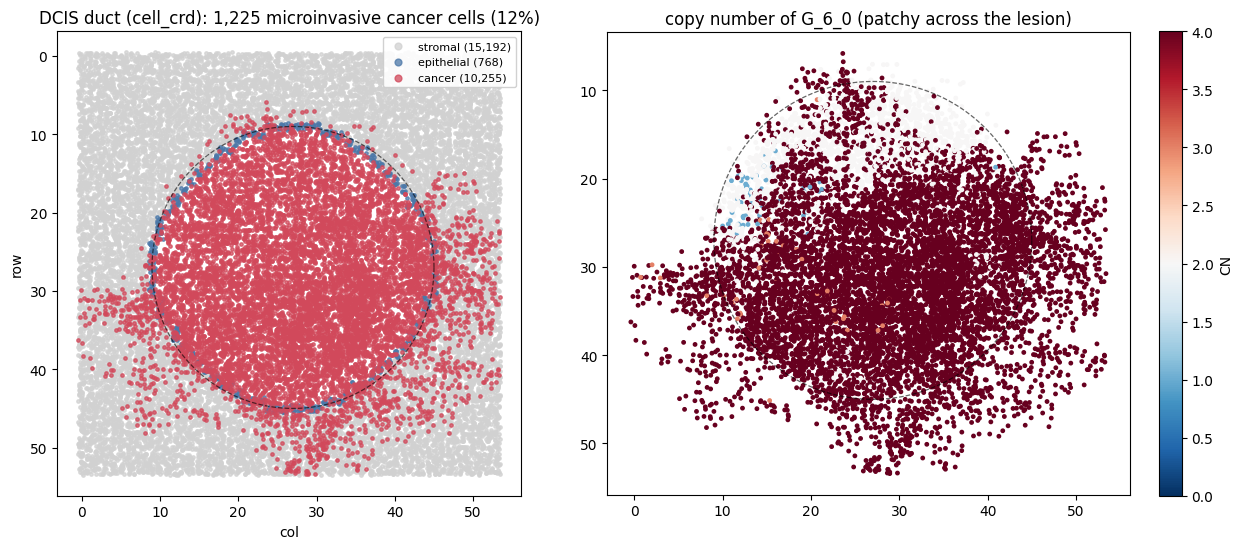

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.45, 0.45, len(crd))
jy = crd["row"].values + jit.uniform(-0.45, 0.45, len(crd))
rad = B.cell_radius(t); R = B.SPATIAL["structure_radius"]
invaded = cancer & (rad > R + 1)

# a gene with strong spatial copy-number variation
seg, gene_seg = B.segment_cn(t)
gvar = cd["cell_cnv"].values[cancer].var(0)
gname = cd["cell_cnv"].columns[int(np.argmax(gvar))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
palette = {"stromal": "0.82", "epithelial": "#4c78a8", "cancer": "#d1495b"}
for name, col in palette.items():
    m = ty == name
    axes[0].scatter(jx[m], jy[m], s=6, c=col, alpha=0.75, label=f"{name} ({m.sum():,})")
B.gland_ring(axes[0]); axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].legend(loc="upper right", fontsize=8, framealpha=0.9, markerscale=2)
axes[0].set_title(f"DCIS duct (cell_crd): {int(invaded.sum()):,} microinvasive cancer cells "
                  f"({invaded.sum()/n_cancer:.0%})")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

s = axes[1].scatter(jx[cancer], jy[cancer], s=6, c=cd["cell_cnv"].values[cancer, list(cd['cell_cnv'].columns).index(gname)],
                    cmap="RdBu_r", vmin=0, vmax=4)
B.gland_ring(axes[1]); axes[1].set_aspect("equal"); axes[1].invert_yaxis()
axes[1].set_title(f"copy number of {gname} (patchy across the lesion)")
plt.colorbar(s, ax=axes[1], fraction=0.046, label="CN")
plt.tight_layout()

## 3. Selection and the microenvironment, made visible

This is the biology every downstream notebook leans on. Six ground-truth fields over the same lattice:

* **division_rate** — the CINner fitness. Weak drivers keep it **distributed** (a gradient of clones,
  including low-fitness ones), not a saturated sheet.
* **dispersal_rate** — a rare motility switch; an independent axis from fitness.
* **proliferation / EMT / hypoxia programs** — the expression layer. By construction proliferation
  tracks division, EMT tracks dispersal, and hypoxia tracks the O₂-starved **core**. The correlations
  in the titles are measured on this tumour, cancer cells only.

cancer at fitness ceiling: 63%  (the rest form the gradient)
proliferation~division r=0.99 | EMT~dispersal r=0.99 | hypoxia~core r=0.76


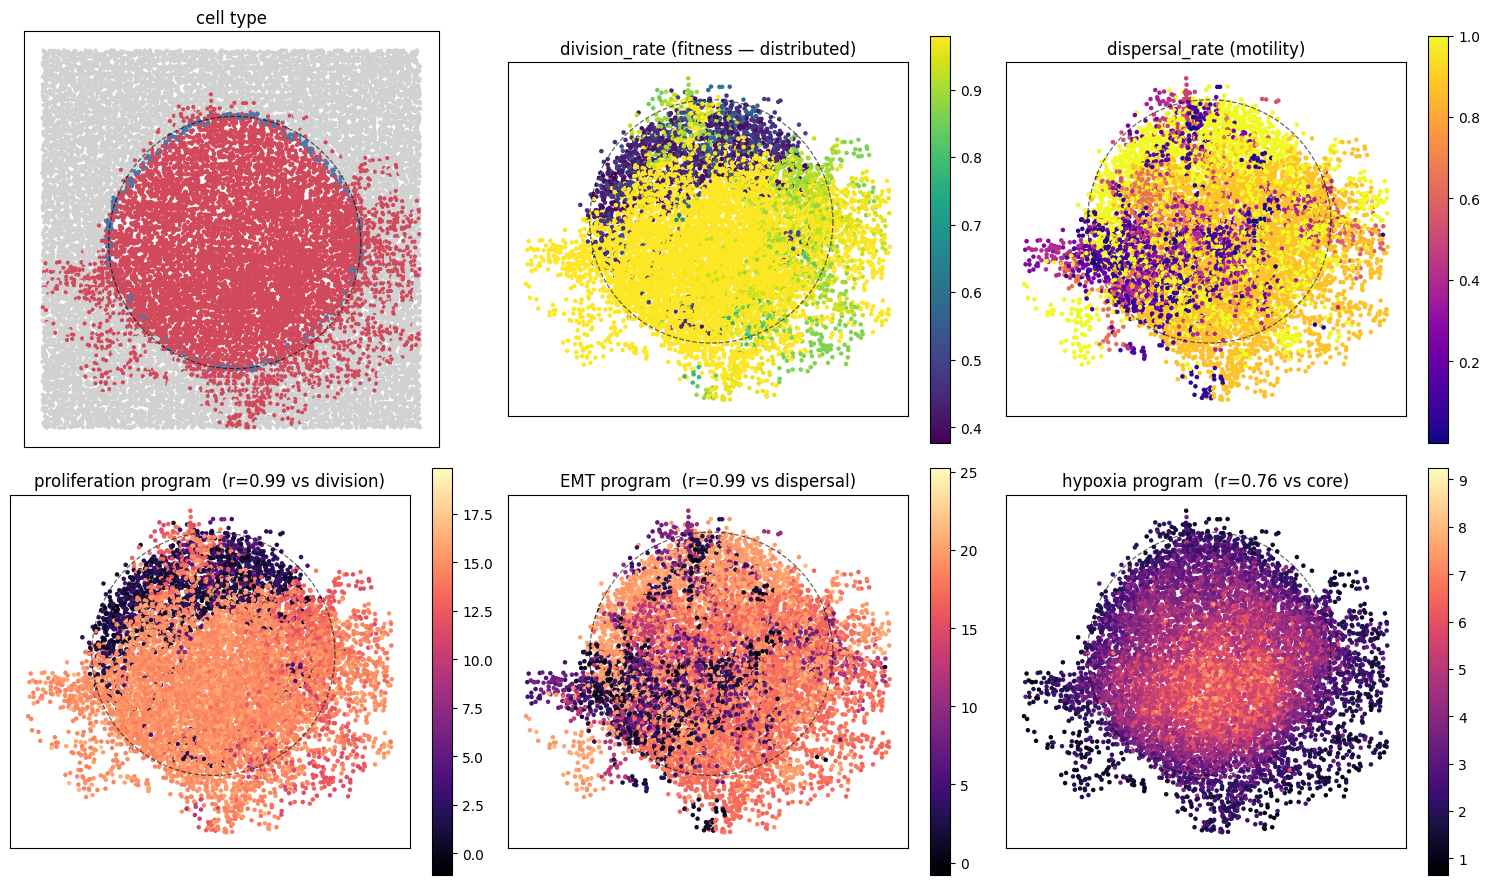

In [4]:
div  = B.cell_rate(t, "division_rate")
disp = B.cell_rate(t, "dispersal_rate")
prol = B.cell_program(t, "proliferation")
emt  = B.cell_program(t, "emt")
hyp  = B.cell_program(t, "hypoxia")

def _corr(a, b, m):
    a, b = a[m], b[m]
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3 or a[ok].std() < 1e-9 or b[ok].std() < 1e-9:
        return float("nan")
    return float(np.corrcoef(a[ok], b[ok])[0, 1])

c = cancer
r_pd = _corr(prol, div, c); r_ed = _corr(emt, disp, c); r_hr = _corr(hyp, -rad, c)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
def panel(a, vals, title, cmap, only_cancer=True):
    m = c & np.isfinite(vals) if only_cancer else np.isfinite(vals)
    sc = a.scatter(jx[m], jy[m], s=5, c=vals[m], cmap=cmap)
    B.gland_ring(a); a.set_aspect("equal"); a.invert_yaxis()
    a.set_xticks([]); a.set_yticks([]); a.set_title(title)
    plt.colorbar(sc, ax=a, fraction=0.046)

cols = np.array([palette.get(x, "#999") for x in ty])
ax[0,0].scatter(jx, jy, s=4, c=cols); B.gland_ring(ax[0,0])
ax[0,0].set_aspect("equal"); ax[0,0].invert_yaxis(); ax[0,0].set_xticks([]); ax[0,0].set_yticks([])
ax[0,0].set_title("cell type")
panel(ax[0,1], div,  "division_rate (fitness — distributed)", "viridis")
panel(ax[0,2], disp, "dispersal_rate (motility)", "plasma")
panel(ax[1,0], prol, f"proliferation program  (r={r_pd:.2f} vs division)", "magma")
panel(ax[1,1], emt,  f"EMT program  (r={r_ed:.2f} vs dispersal)", "magma")
panel(ax[1,2], hyp,  f"hypoxia program  (r={r_hr:.2f} vs core)", "magma")
plt.tight_layout()
print(f"cancer at fitness ceiling: {(div[c]>0.97).mean():.0%}  (the rest form the gradient)")
print(f"proliferation~division r={r_pd:.2f} | EMT~dispersal r={r_ed:.2f} | hypoxia~core r={r_hr:.2f}")

## 4. The ground-truth matrices

The per-cell matrices in `cell_data` are what every downstream notebook reads. Ordered normal-then-
cancer, the structure is already visible: **SNVs** accumulate in malignant cells, **copy number**
departs from the diploid (CN=2) normal baseline, and **expression** carries both the copy-number
dosage and the gene-program signal.

dashed line = normal/cancer split;  cell_data keys: ['cell_evo', 'cell_snv', 'cell_cnv', 'cell_exp', 'cell_crd', 'cell_type', 'cell_deme', 'cell_rna_vaf', 'cell_wgd', 'cell_microenv', 'cell_exp_p', 'cell_exp_m', 'cell_rna_baf', 'cell_program']


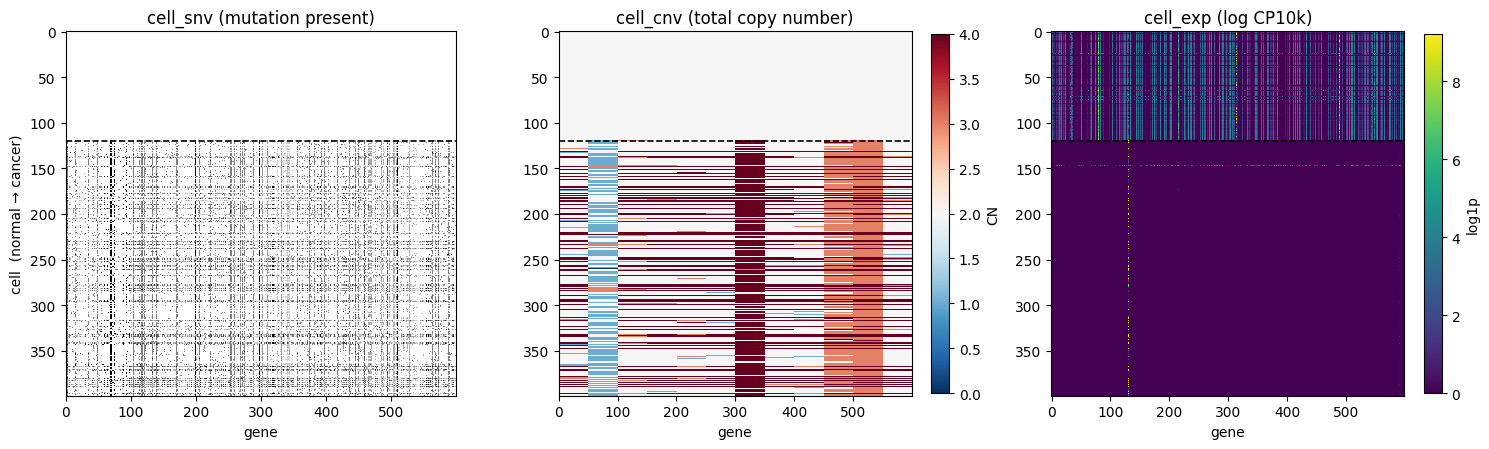

In [5]:
rng = np.random.default_rng(0)
order = np.concatenate([rng.permutation(np.where(~cancer)[0])[:120],
                        rng.permutation(np.where(cancer)[0])[:280]])
split = 120

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].imshow(cd["cell_snv"].values[order], aspect="auto", cmap="binary", interpolation="none")
axes[0].set_title("cell_snv (mutation present)"); axes[0].set_xlabel("gene")
axes[0].set_ylabel("cell  (normal → cancer)")

im1 = axes[1].imshow(cd["cell_cnv"].values[order], aspect="auto", cmap="RdBu_r", vmin=0, vmax=4,
                     interpolation="none")
axes[1].set_title("cell_cnv (total copy number)"); axes[1].set_xlabel("gene")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="CN")

E = cd["cell_exp"].values[order]
im2 = axes[2].imshow(np.log1p(E / E.sum(1, keepdims=True) * 1e4), aspect="auto", cmap="viridis",
                     interpolation="none")
axes[2].set_title("cell_exp (log CP10k)"); axes[2].set_xlabel("gene")
plt.colorbar(im2, ax=axes[2], fraction=0.046, label="log1p")
for ax_ in axes:
    ax_.axhline(split, color="k", lw=1.2, ls="--")
plt.tight_layout()
print("dashed line = normal/cancer split;  cell_data keys:", list(cd.keys()))

## 5. What each notebook uses

| notebook | reads | recovers (scored vs iscc ground truth) |
|---|---|---|
| [`combining_scdna_scrna`](combining_scdna_scrna.ipynb) | `cell_cnv`, `cell_exp` (scDNA + scRNA) | subclones from RNA via DNA-defined CN profiles (clonealign idea) |
| [`wgd_allele_cna`](wgd_allele_cna.ipynb) | `cell_wgd`, allele CN, `cell_rna_baf` | which copy-number states are allele-only detectable, and the WGD ploidy signature |
| [`gene_programs`](gene_programs.ipynb) | `cell_program`, `cell_exp`, `program_truth` | expression programs vs the contiguous-CNA confound (NMF), and that they track division/dispersal/core |
| [`tree_inference_dna`](tree_inference_dna.ipynb) | `cell_snv`, bulk/scDNA, `genotypes_parents` | the clonal phylogeny, from bulk VAF and from single cells |
| [`scrna_visium_integration`](scrna_visium_integration.ipynb) | Visium spots + scRNA reference | per-spot cell-type composition by NNLS deconvolution |
| [`cohort_shared_programs`](cohort_shared_programs.ipynb) | 5 tumours (shared landscape) | programs shared across patients despite batch effects (scDEF / NMF) |
| [`cohort_mhn_recurrence`](cohort_mhn_recurrence.ipynb) | 5 tumours, driver events | recurrent mutations + their interactions/order (MHN / TreeMHN) |

**Next:** open any notebook above — each starts with the same `from base_sim import grow_base_tumor`.
The mechanics live in [`01_pipeline_walkthrough`](01_pipeline_walkthrough.ipynb),
[`03_data_overview`](03_data_overview.ipynb) and the [`assay_*`](assay_scrna.ipynb) notebooks; the
production-tool benchmarks live under `validation/`.